# Día 3 — resample, rolling, cumsum: el gap ladder de liquidez
### Preparación entrevista técnica Ebury (Treasury/ALM)

Hoy juntamos todo lo de los días anteriores para construir el tipo de output más directamente relacionado con las tareas reales que describía esa persona de Ebury: una tabla de exposición **acumulada** por divisa y plazo — el "liquidity gap ladder".


In [37]:
import pandas as pd
import numpy as np
pd.set_option('display.width', 1000)

In [1]:


np.random.seed(1) # So that we always generate the same numbers when generating "random" numbers
n = 30
df = pd.DataFrame({
    "id_transaccion": range(1, n + 1),
    "divisa": np.random.choice(["USD", "EUR", "GBP"], n),
    "importe": np.round(np.random.uniform(-150000, 150000, n), 2),
    "fecha_vencimiento": pd.to_datetime("2026-08-26") + pd.to_timedelta(np.random.randint(1, 200, n), unit="D")
})
df = df.sort_values("fecha_vencimiento").reset_index(drop=True)
df.head(10)


,id_transaccion,divisa,importe,fecha_vencimiento
0,29,GBP,121011.05,2026-08-29
1,24,GBP,-16159.65,2026-08-30
2,26,USD,-127990.75,2026-09-02
3,9,USD,-68085.01,2026-09-06
4,10,EUR,-132227.04,2026-09-19
5,13,EUR,51496.23,2026-09-21
6,7,USD,98744.07,2026-09-28
7,17,EUR,-107363.96,2026-10-12
8,27,EUR,-9228.44,2026-10-18
9,3,USD,90827.25,2026-10-23


## Parte 1 — `cumsum()`: la base de cualquier gap acumulado

`cumsum()` (suma acumulada) va sumando cada valor con todos los anteriores, en el orden en que aparecen las filas. Es la pieza central de un gap ladder: "¿cuánta exposición neta tengo acumulada hasta este plazo, contando todo lo que vence antes?".

In [2]:
ejemplo = pd.Series([10, -5, 20, -15, 8])
print(ejemplo.cumsum())


0    10
1     5
2    25
3    10
4    18
dtype: int64


**Importante**: `cumsum()` depende completamente del **orden** de las filas. Si tus datos no están ordenados por fecha antes de aplicar `cumsum()`, el resultado no significará nada — es el error más fácil de cometer con esta función.

In [4]:
# Mal: si el DataFrame no está ordenado por fecha, el acumulado no tiene sentido temporal
df_desordenado = df.sample(frac=1, random_state=5)  # desordena las filas a propósito
print(df_desordenado["importe"].cumsum().head())   # esto NO es un gap ladder válido

# Bien: ordena primero por la variable temporal
df_ordenado = df.sort_values("fecha_vencimiento")
print(df_ordenado["importe"].cumsum().head())


11    -90734.73
29   -211883.05
23   -126888.71
25    -62097.56
18   -145460.20
Name: importe, dtype: float64
0    121011.05
1    104851.40
2    -23139.35
3    -91224.36
4   -223451.40
Name: importe, dtype: float64


### Ejercicio 1.1
Calcula el importe acumulado (`cumsum`) de `df` (ya está ordenado por fecha), pero por separado para cada divisa — es decir, el acumulado de USD no debe mezclarse con el de EUR.

In [60]:
# TODO: pista, groupby + cumsum se pueden
df["acumulado"] = df.dropna(subset=["importe"]).groupby("divisa")["importe"].cumsum()

print(df[["divisa", "fecha_vencimiento", "importe", "acumulado"]].head(10))


   id_transaccion divisa    importe fecha_vencimiento  acumulado  media_movil_3     suma5  suma_movil_5  dias_hasta_vencimiento tenor_bucket
0              29    GBP  121011.05        2026-08-29  121011.05            NaN       NaN           NaN                       3         0-7d
1              24    GBP  -16159.65        2026-08-30  104851.40            NaN       NaN           NaN                       4         0-7d
2              26    USD -127990.75        2026-09-02 -127990.75   -7713.116667       NaN           NaN                       7         0-7d
3               9    USD  -68085.01        2026-09-06 -196075.76  -70745.136667       NaN           NaN                      11        7-30d
4              10    EUR -132227.04        2026-09-19 -132227.04 -109434.266667 -223451.4     -223451.4                      24        7-30d
  divisa fecha_vencimiento    importe  acumulado
0    GBP        2026-08-29  121011.05  121011.05
1    GBP        2026-08-30  -16159.65  104851.40
2    US

**Solución 1.1**

In [ ]:
df["acumulado"] = df.groupby("divisa")["importe"].cumsum()
print(df[["divisa", "fecha_vencimiento", "importe", "acumulado"]].head(10))


> Fíjate en el patrón: `groupby("divisa")["importe"].cumsum()` — a diferencia de `.sum()`, `cumsum()` no colapsa las filas en una sola por grupo, sino que devuelve **una fila por cada fila original**, con el acumulado dentro de su grupo. Esto es distinto a lo que has visto hasta ahora con groupby, así que vale la pena que lo notes.

## Parte 2 — `resample()`: agregación por periodos de tiempo

`resample()` es como un `groupby`, pero específico para fechas — agrupa automáticamente por intervalos de tiempo regulares (semana, mes, trimestre...), sin que tengas que crear tú una columna de "bucket" a mano. Requiere que la fecha sea el índice del DataFrame.

In [13]:
df_indexado = df.set_index("fecha_vencimiento") #Esto te pone la columna que elijas como índice

# Importe total por semana
semanal = df_indexado["importe"].resample("W").sum()
print(semanal.head())


fecha_vencimiento
2026-08-30    104851.40
2026-09-06   -196075.76
2026-09-13         0.00
2026-09-20   -132227.04
2026-09-27     51496.23
Freq: W-SUN, Name: importe, dtype: float64


In [12]:
# Importe total por mes
mensual = df_indexado["importe"].resample("ME").sum()   # "ME" = Month End
print(mensual)


fecha_vencimiento
2026-08-31    104851.40
2026-09-30   -178062.50
2026-10-31     11443.85
2026-11-30   -386042.74
2026-12-31     48190.72
2027-01-31    134580.27
2027-02-28    114363.65
2027-03-31   -184259.43
Freq: ME, Name: importe, dtype: float64


### Ejercicio 2.1
Usando `resample`, calcula el importe medio (`mean`) por mes.

In [61]:
# TODO
df_indexado=df.set_index("fecha_vencimiento")
resultado =df_indexado["importe"].resample("ME").mean()
print(resultado)

fecha_vencimiento
2026-08-31    52425.700000
2026-09-30   -35612.500000
2026-10-31     2860.962500
2026-11-30   -64340.456667
2026-12-31    48190.720000
2027-01-31    26916.054000
2027-02-28    22872.730000
2027-03-31   -92129.715000
Freq: ME, Name: importe, dtype: float64
fecha_vencimiento
2026-08-31    52425.700000
2026-09-30   -35612.500000
2026-10-31     2860.962500
2026-11-30   -64340.456667
2026-12-31    48190.720000
2027-01-31    26916.054000
2027-02-28    22872.730000
2027-03-31   -92129.715000
Freq: ME, Name: importe, dtype: float64


**Solución 2.1**

In [ ]:
resultado = df_indexado["importe"].resample("ME").mean()
print(resultado)


## Parte 3 — `rolling()`: ventanas móviles

Calcula una métrica (media, suma...) sobre una "ventana" de N observaciones consecutivas, que se va desplazando. Útil para suavizar tendencias o ver comportamiento reciente sin que un solo valor extremo lo distorsione todo.

In [20]:
df["media_movil_3"] = df["importe"].rolling(window=3).mean()
print(df[["fecha_vencimiento", "importe", "media_movil_3"]].head(8))


  fecha_vencimiento    importe  media_movil_3
0        2026-08-29  121011.05            NaN
1        2026-08-30  -16159.65            NaN
2        2026-09-02 -127990.75   -7713.116667
3        2026-09-06  -68085.01  -70745.136667
4        2026-09-19 -132227.04 -109434.266667
5        2026-09-21   51496.23  -49605.273333
6        2026-09-28   98744.07    6004.420000
7        2026-10-12 -107363.96   14292.113333


> Fíjate que las primeras 2 filas dan `NaN` — con `window=3`, hacen falta al menos 3 observaciones para poder calcular la primera media móvil. Esto es normal, no un error.

### Ejercicio 3.1
Calcula la suma móvil (no la media) de los últimos 5 importes, sin agrupar por divisa.

In [31]:
# TODO

df["suma5"]=df["importe"].rolling(window=5).sum()
print(df[["fecha_vencimiento","divisa","importe","suma5"]].head(8))



  fecha_vencimiento divisa    importe      suma5
0        2026-08-29    GBP  121011.05        NaN
1        2026-08-30    GBP  -16159.65        NaN
2        2026-09-02    USD -127990.75        NaN
3        2026-09-06    USD  -68085.01        NaN
4        2026-09-19    EUR -132227.04 -223451.40
5        2026-09-21    EUR   51496.23 -292966.22
6        2026-09-28    USD   98744.07 -178062.50
7        2026-10-12    EUR -107363.96 -157435.71


**Solución 3.1**

In [32]:
df["suma_movil_5"] = df["importe"].rolling(window=5).sum()
print(df[["fecha_vencimiento", "importe", "suma_movil_5"]].head(8))


  fecha_vencimiento    importe  suma_movil_5
0        2026-08-29  121011.05           NaN
1        2026-08-30  -16159.65           NaN
2        2026-09-02 -127990.75           NaN
3        2026-09-06  -68085.01           NaN
4        2026-09-19 -132227.04    -223451.40
5        2026-09-21   51496.23    -292966.22
6        2026-09-28   98744.07    -178062.50
7        2026-10-12 -107363.96    -157435.71


---
## Parte 4 — Construir un gap ladder de liquidez completo (el ejercicio más importante de hoy)

Ahora juntamos todo: `pd.cut()` para buckets de plazo (Día 2), `pivot_table` (Día 2), y `cumsum()` (hoy) — con un detalle nuevo importante: el **orden correcto de los buckets**, porque un acumulado solo tiene sentido si los buckets están en orden cronológico, no alfabético.

In [49]:
hoy = pd.Timestamp("2026-08-26")
df["dias_hasta_vencimiento"] = (df["fecha_vencimiento"] - hoy).dt.days

bins = [0, 7, 30, 90, 180, np.inf]
labels = ["0-7d", "7-30d", "30-90d", "90-180d", ">180d"]

# ordered=True es clave: le dice a pandas que estas categorías tienen un orden lógico,
# no alfabético. Sin esto, el cumsum posterior saldría en el orden equivocado.
df["tenor_bucket"] = pd.cut(df["dias_hasta_vencimiento"], bins=bins, labels=labels, ordered=True)

print(df[["fecha_vencimiento", "dias_hasta_vencimiento", "tenor_bucket"]].head(10))


  fecha_vencimiento  dias_hasta_vencimiento tenor_bucket
0        2026-08-29                       3         0-7d
1        2026-08-30                       4         0-7d
2        2026-09-02                       7         0-7d
3        2026-09-06                      11        7-30d
4        2026-09-19                      24        7-30d
5        2026-09-21                      26        7-30d
6        2026-09-28                      33       30-90d
7        2026-10-12                      47       30-90d
8        2026-10-18                      53       30-90d
9        2026-10-23                      58       30-90d


In [40]:
# Paso 1: importe neto por divisa y bucket
tabla = df.pivot_table(
    index="tenor_bucket",
    columns="divisa",
    values="importe",
    aggfunc="sum",
    fill_value=0,
    observed=False
)

# Paso 2: reindexar explícitamente en el orden correcto de los buckets (por seguridad)
tabla = tabla.reindex(labels)
print("Exposición neta por bucket:")
print(tabla)


Exposición neta por bucket:
divisa              EUR        GBP        USD
tenor_bucket                                 
0-7d               0.00  104851.40 -127990.75
7-30d         -80730.81       0.00  -68085.01
30-90d       -299203.57   65128.66  -15316.27
90-180d       187843.54  -24831.94  247408.01
>180d        -121148.32  -63111.11 -139748.61


In [39]:
# Paso 3: el gap ladder real -- acumular hacia adelante en el tiempo
gap_ladder = tabla.cumsum()
print("Gap ladder acumulado:")
print(gap_ladder)


Gap ladder acumulado:
divisa              EUR        GBP        USD
tenor_bucket                                 
0-7d               0.00  104851.40 -127990.75
7-30d         -80730.81  104851.40 -196075.76
30-90d       -379934.38  169980.06 -211392.03
90-180d      -192090.84  145148.12   36015.98
>180d        -313239.16   82037.01 -103732.63


**Cómo se lee esta tabla, e importante que sepas explicarlo en la entrevista**: cada fila no muestra solo lo que vence en ese bucket — muestra la exposición **acumulada hasta ese plazo, inclusive**. Si en la fila "30-90d" ves -200.000 en USD, significa "si sumamos todo lo que vence entre hoy y 90 días, el neto es -200.000" — no "lo que vence específicamente en ese rango". Esta es la pregunta que más suelen hacer para comprobar que entiendes lo que has calculado, no solo que sepas escribir el código.

### Ejercicio 4.1
Identifica en qué bucket(s) el gap acumulado de alguna divisa es negativo y supera, en valor absoluto, los 100.000 — es decir, un posible problema de liquidez señalado por el propio gap ladder.

In [84]:
# TODO
#df=df.drop(columns=["dias_hasta_vencimiento","tenor_bucket"])

# Add días de vencimiento
df["dias_hasta_vencimiento"]=(df["fecha_vencimiento"]-pd.Timestamp("2026-08-26")).dt.days

# Add a bucket
bins=[-np.inf,7,30,90,180,np.inf]
labels=["0-7d", "7-30d", "30-90d", "90-180d", ">180d"]
df["tenor_bucket"]=pd.cut(df["dias_hasta_vencimiento"], bins=bins, labels=labels,ordered=True)
#print(df)

# Build gap ladder
gap_laddert=df.pivot_table(index= "tenor_bucket", columns="divisa", values="importe", aggfunc="sum",fill_value=0,observed=False)
print(gap_laddert)

## FIRST WAY: THROUGH loc
# Add accumulated ladder
gap_laddert=gap_laddert.cumsum()
print(gap_laddert)
alertas=[]
for bucket in gap_laddert.index:
    subset=gap_laddert[gap_laddert.index==bucket]
    for div in gap_laddert.columns:
        if (gap_laddert.loc[bucket,div]<0) & (abs(gap_laddert.loc[bucket,div])>100000):
            alertas.append({
                "bucket_alert":bucket,
                "curr_alert":div,
                "value_alert":gap_laddert.loc[bucket,div]
            }
            )
alertas=pd.DataFrame(alertas)
print(alertas)

## SECOND WAY: THROUGH iloc
alertas2=[]
for i in range(gap_laddert.shape[0]):
    for j in range(gap_laddert.shape[1]):
        if (gap_laddert.iloc[i,j])<0 & (abs(gap_laddert.iloc[i,j])>100000):
            alertas2.append({
                "bucket_alert":gap_laddert.index[i],
                "curr_alert":gap_laddert.columns[j],
                "value_alert":gap_laddert.iloc[i,j]
            }
            )
alertas2=pd.DataFrame(alertas2)
print("--------alertas2--------")
print(alertas2)



print(gap_ladder)
print(type(gap_ladder))

# Method 1: loops
alertas=[]
for i in range(len(gap_ladder)):
     for j in range(gap_ladder.shape[1]):
        if gap_ladder.iloc[i,j]<0 and abs(gap_ladder.iloc[i,j])>100000:
            alertas.append({
                "index": gap_ladder.index[i],
                "column":gap_ladder.columns[j],
                "value": gap_ladder.iloc[i,j]
            })
alertas1df=pd.DataFrame(alertas)
print(alertas1df)

# Method 2:
alertas2=gap_ladder[(gap_ladder<0) & (abs(gap_ladder)>100000)]
print(alertas2)
# alertas =
# print(alertas)


divisa              EUR        GBP        USD
tenor_bucket                                 
0-7d               0.00  104851.40 -127990.75
7-30d         -80730.81       0.00  -68085.01
30-90d       -299203.57   65128.66  -15316.27
90-180d       187843.54  -24831.94  247408.01
>180d        -121148.32  -63111.11 -139748.61
divisa              EUR        GBP        USD
tenor_bucket                                 
0-7d               0.00  104851.40 -127990.75
7-30d         -80730.81  104851.40 -196075.76
30-90d       -379934.38  169980.06 -211392.03
90-180d      -192090.84  145148.12   36015.98
>180d        -313239.16   82037.01 -103732.63
  bucket_alert curr_alert  value_alert
0         0-7d        USD   -127990.75
1        7-30d        USD   -196075.76
2       30-90d        EUR   -379934.38
3       30-90d        USD   -211392.03
4      90-180d        EUR   -192090.84
5        >180d        EUR   -313239.16
6        >180d        USD   -103732.63
--------alertas2--------
  bucket_alert curr

**Solución 4.1**

In [80]:
alertas = gap_ladder[(gap_ladder < -100000).any(axis=1)]
print(alertas)

# Alternativa más explícita, mostrando divisa y bucket exactos:
for bucket in gap_ladder.index:
    for divisa in gap_ladder.columns:
        valor = gap_ladder.loc[bucket, divisa]
        if valor < -100000:
            print(f"Alerta: {divisa} en bucket {bucket} tiene gap acumulado de {valor:,.0f}")


divisa              EUR        GBP        USD
tenor_bucket                                 
0-7d               0.00  104851.40 -127990.75
7-30d         -80730.81  104851.40 -196075.76
30-90d       -379934.38  169980.06 -211392.03
90-180d      -192090.84  145148.12   36015.98
>180d        -313239.16   82037.01 -103732.63
Alerta: USD en bucket 0-7d tiene gap acumulado de -127,991
Alerta: USD en bucket 7-30d tiene gap acumulado de -196,076
Alerta: EUR en bucket 30-90d tiene gap acumulado de -379,934
Alerta: USD en bucket 30-90d tiene gap acumulado de -211,392
Alerta: EUR en bucket 90-180d tiene gap acumulado de -192,091
Alerta: EUR en bucket >180d tiene gap acumulado de -313,239
Alerta: USD en bucket >180d tiene gap acumulado de -103,733


---
## Parte 5 — Un gráfico simple, por si piden algo tipo "dashboard"

No hace falta que sea sofisticado — un gráfico de barras o líneas simple con matplotlib suele ser suficiente para demostrar que sabes comunicar un resultado visualmente, no solo en una tabla.

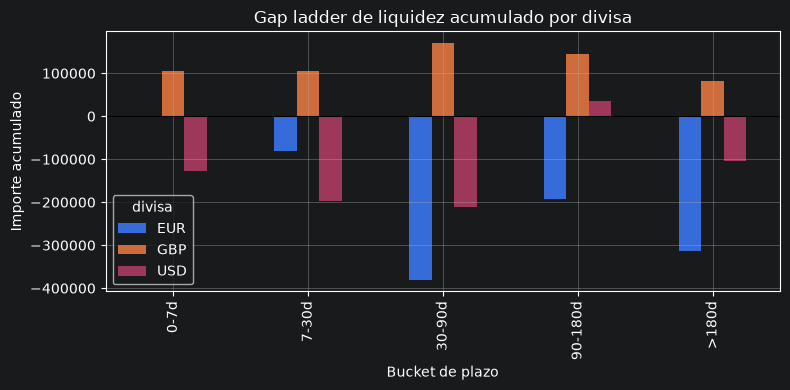

In [ ]:
import matplotlib.pyplot as plt

gap_ladder.plot(kind="bar", figsize=(8, 4))
plt.title("Gap ladder de liquidez acumulado por divisa")
plt.ylabel("Importe acumulado")
plt.xlabel("Bucket de plazo")
plt.axhline(0, color="black", linewidth=0.8)   # línea en el cero, para ver visualmente positivo/negativo
plt.tight_layout()
plt.grid()
plt.show()

gap_ladder.plot(style='o-')
# Option 1
plt.legend(labels=["EUR","GBP","USD"],title="Divisa")
# Option 2
plt.legend(title="Divisa")
# Option 3
nice_names= {"EUR": "Euro", "GBP": "Libra", "JPY": "Yen", "USD": "Dólar"}
plt.legend(labels=[nice_names[col] for col in gap_ladder.columns], title="Divisa")
plt.grid()
plt.show()


---
## Resumen del Día 3 — lo que deberías dominar ahora
- `cumsum()`, y por qué el orden de las filas es crítico antes de aplicarlo — combinado con `groupby` cuando necesitas acumulados independientes por grupo.
- `resample()` para agregar por periodos de tiempo regulares, cuando la fecha es el índice.
- `rolling()` para medias/sumas móviles, y por qué las primeras filas salen `NaN`.
- Cómo construir un **gap ladder de liquidez completo**: buckets ordenados con `pd.cut(..., ordered=True)`, `pivot_table` para la exposición neta, y `cumsum()` para el acumulado — y sobre todo, **cómo explicar en una frase qué significa cada valor de la tabla**.
- Un gráfico simple con matplotlib, por si piden visualización tipo dashboard.

Con esto, ya tienes cubierto de principio a fin el tipo de tarea más probable el lunes: cargar datos (Día 2b) → limpiarlos y combinarlos (Día 1-2) → construir un gap ladder acumulado (Día 3) → comunicarlo con una tabla y un gráfico. Mañana (Día 4) reforzamos la misma lógica pero en SQL, con funciones de ventana.